Saving RadioML.xlsx to RadioML (13).xlsx


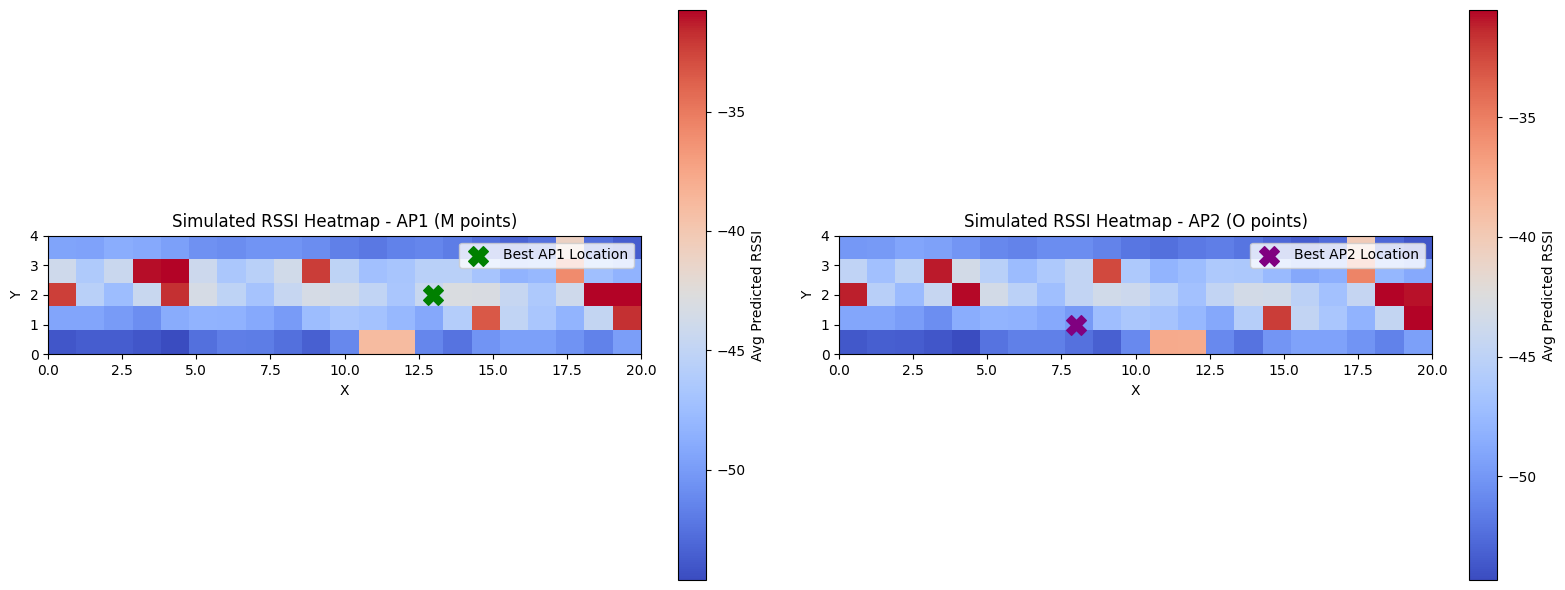


 Best AP1 location: X=13, Y=2 (Avg RSSI ≈ -30.74 dBm)
📡 AP1 coverage (> -50 dBm): 68.57% of area

 Best AP2 location: X=8, Y=1 (Avg RSSI ≈ -30.51 dBm)
📡 AP2 coverage (> -50 dBm): 68.57% of area


In [13]:
# Upload your RadioML.xlsx
from google.colab import files
uploaded = files.upload()

# Install dependencies
!pip install -q pandas numpy matplotlib seaborn openpyxl

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
filename = next(iter(uploaded))
df = pd.read_excel(filename)

# Clean
df["X"] = pd.to_numeric(df["X"], errors="coerce")
df["Y"] = pd.to_numeric(df["Y"], errors="coerce")
df["RSSI"] = pd.to_numeric(df["RSSI"], errors="coerce")
df = df.dropna(subset=["X", "Y", "RSSI"])

# Constants
n = 2.5             # Path loss exponent
tx_power = -30      # RSSI at 1m
threshold = -50     # dBm threshold for coverage

# ----------------------------
# 🟢 AP1 Simulation (M points)
# ----------------------------
df_ap1 = df[df["ReadingID"].astype(str).str.startswith("M")].copy()

x_range1 = np.arange(0, max(5, df_ap1["X"].max() + 1))  # ensure wider X/Y even if data is small
y_range1 = np.arange(0, max(5, df_ap1["Y"].max() + 1))

scores_ap1 = []
positions_ap1 = []

for x_ap in x_range1:
    for y_ap in y_range1:
        distances = np.sqrt((df_ap1["X"] - x_ap)**2 + (df_ap1["Y"] - y_ap)**2)
        predicted_rssi = tx_power - 10 * n * np.log10(distances + 1e-6)
        score = predicted_rssi.mean()
        scores_ap1.append(score)
        positions_ap1.append((x_ap, y_ap))

best_idx_ap1 = np.argmax(scores_ap1)
best_pos_ap1 = positions_ap1[best_idx_ap1]
best_score_ap1 = scores_ap1[best_idx_ap1]

score_grid_ap1 = np.array(scores_ap1).reshape(len(y_range1), len(x_range1))

# Coverage for AP1
coverage_ap1 = np.mean(score_grid_ap1 > threshold) * 100

# ----------------------------
# 🟣 AP2 Simulation (O points)
# ----------------------------
df_ap2 = df[df["ReadingID"].astype(str).str.startswith("O")].copy()

x_range2 = np.arange(0, max(5, df_ap2["X"].max() + 1))
y_range2 = np.arange(0, max(5, df_ap2["Y"].max() + 1))

scores_ap2 = []
positions_ap2 = []

for x_ap in x_range2:
    for y_ap in y_range2:
        distances = np.sqrt((df_ap2["X"] - x_ap)**2 + (df_ap2["Y"] - y_ap)**2)
        predicted_rssi = tx_power - 10 * n * np.log10(distances + 1e-6)
        score = predicted_rssi.mean()
        scores_ap2.append(score)
        positions_ap2.append((x_ap, y_ap))

best_idx_ap2 = np.argmax(scores_ap2)
best_pos_ap2 = positions_ap2[best_idx_ap2]
best_score_ap2 = scores_ap2[best_idx_ap2]

score_grid_ap2 = np.array(scores_ap2).reshape(len(y_range2), len(x_range2))

# Coverage for AP2
coverage_ap2 = np.mean(score_grid_ap2 > threshold) * 100

# ----------------------------
# Visualization
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AP1
im1 = axes[0].imshow(score_grid_ap1, origin='lower', cmap='coolwarm',
                     extent=[x_range1.min(), x_range1.max(), y_range1.min(), y_range1.max()])
axes[0].scatter(*best_pos_ap1, c='green', marker='X', s=200, label="Best AP1 Location")
axes[0].set_title("Simulated RSSI Heatmap - AP1 (M points)")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].legend()
fig.colorbar(im1, ax=axes[0], label="Avg Predicted RSSI")

# AP2
im2 = axes[1].imshow(score_grid_ap2, origin='lower', cmap='coolwarm',
                     extent=[x_range2.min(), x_range2.max(), y_range2.min(), y_range2.max()])
axes[1].scatter(*best_pos_ap2, c='purple', marker='X', s=200, label="Best AP2 Location")
axes[1].set_title("Simulated RSSI Heatmap - AP2 (O points)")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].legend()
fig.colorbar(im2, ax=axes[1], label="Avg Predicted RSSI")

plt.tight_layout()
plt.show()

# ----------------------------
# Results & Coverage
# ----------------------------
print(f"\n Best AP1 location: X={best_pos_ap1[0]}, Y={best_pos_ap1[1]} (Avg RSSI ≈ {best_score_ap1:.2f} dBm)")
print(f"📡 AP1 coverage (> {threshold} dBm): {coverage_ap1:.2f}% of area")

print(f"\n Best AP2 location: X={best_pos_ap2[0]}, Y={best_pos_ap2[1]} (Avg RSSI ≈ {best_score_ap2:.2f} dBm)")
print(f"📡 AP2 coverage (> {threshold} dBm): {coverage_ap2:.2f}% of area")
